In [262]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import shap
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import shap
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import time
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch.optim as optim

In [263]:
features = pd.read_csv("data/X_cleaned.csv")
output = pd.read_csv("data/y_cleaned.csv")

In [264]:
#independent_vars = ["agemon1", "female1", "stunting1", "underweight1", "bcg1", "measles1", "tetanus1", "has_longterm_disease_r1", "bmi1", "carecantread1", "caregiver_is_female1", "caregiver_is_parent1", "dadage1", "dadedu1", "dadlive1", "momage1", "momedu1", "momlive1", "numante1", "hhsize1", "headage1", "headedu1", "headsex1", "ownlandhse1", "typesite1", "cookingq1", "drwaterq1", "elecq1", "toiletq1", "aniany1", "sv1", "injury_child_may_die_r1", "sees_dad_daily_r1", "sees_mom_daily_r1", "health_worse_than_others_r1"]
#dependent_vars = ['bmi5', 'stunting5', 'thinness5', 'chhealth5', 'z_selfefficacy_r5', 'z_agency_r5', 'z_selfsteem_r5', 'z_peersr5', 'z_pride_r5', 'z_relationparents_r5']

In [265]:
# remove dadlive1, momlive1 because all record is constant 1.
#  not include health variables in dependent_vars
independent_vars = ["agemon1", "female1", "stunting1", "underweight1", "bcg1", "measles1", "tetanus1", "has_longterm_disease_r1", "bmi1", "carecantread1", "caregiver_is_female1", "caregiver_is_parent1", "dadage1", "dadedu1", "momage1", "momedu1","numante1", "hhsize1", "headage1", "headedu1", "headsex1", "ownlandhse1", "typesite1", "cookingq1", "drwaterq1", "elecq1", "toiletq1", "aniany1", "sv1", "injury_child_may_die_r1", "sees_dad_daily_r1", "sees_mom_daily_r1", "health_worse_than_others_r1"]
dependent_vars = [ 'z_selfefficacy_r5', 'z_agency_r5', 'z_selfsteem_r5', 'z_peersr5', 'z_pride_r5', 'z_relationparents_r5']

In [266]:
df = pd.concat([features, output], axis=1)

In [267]:
X = df[independent_vars]
y = df[dependent_vars]

In [268]:
df2 = pd.concat([X, y], axis=1)

In [269]:
df.head()
# df.info()
#df.describe()

,agemon1,female1,stunting1,underweight1,bcg1,measles1,tetanus1,has_longterm_disease_r1,bmi1,careage1,...,bmi5,stunting5,thinness5,chhealth5,z_selfefficacy_r5,z_agency_r5,z_selfsteem_r5,z_peersr5,z_pride_r5,z_relationparents_r5
0,7,0.0,0,0,1,0,1,0,14.922146,30,...,14.497697,1,2,2,-0.902831,0.405940,-0.593782,-0.197115,1.015500,-1.140962
1,14,0.0,0,0,1,1,1,0,15.547168,25,...,19.965398,0,0,2,-0.666351,-0.233022,0.613296,0.430333,-1.787409,-1.616397
2,11,1.0,0,0,1,1,0,0,15.734185,30,...,17.469445,0,0,2,0.862961,1.068327,-0.134186,0.713549,0.292409,-0.155111
3,12,1.0,0,0,1,1,1,0,15.627442,36,...,19.086428,1,0,2,-1.244954,1.017076,-0.926815,-0.699221,-1.034115,0.147575
4,16,1.0,0,0,1,1,1,0,15.591147,28,...,21.771661,0,0,2,0.383515,0.405940,0.299607,-0.197115,-0.407526,0.421651


In [270]:
corr_matrix = df2.corr()  # Computes pairwise correlations

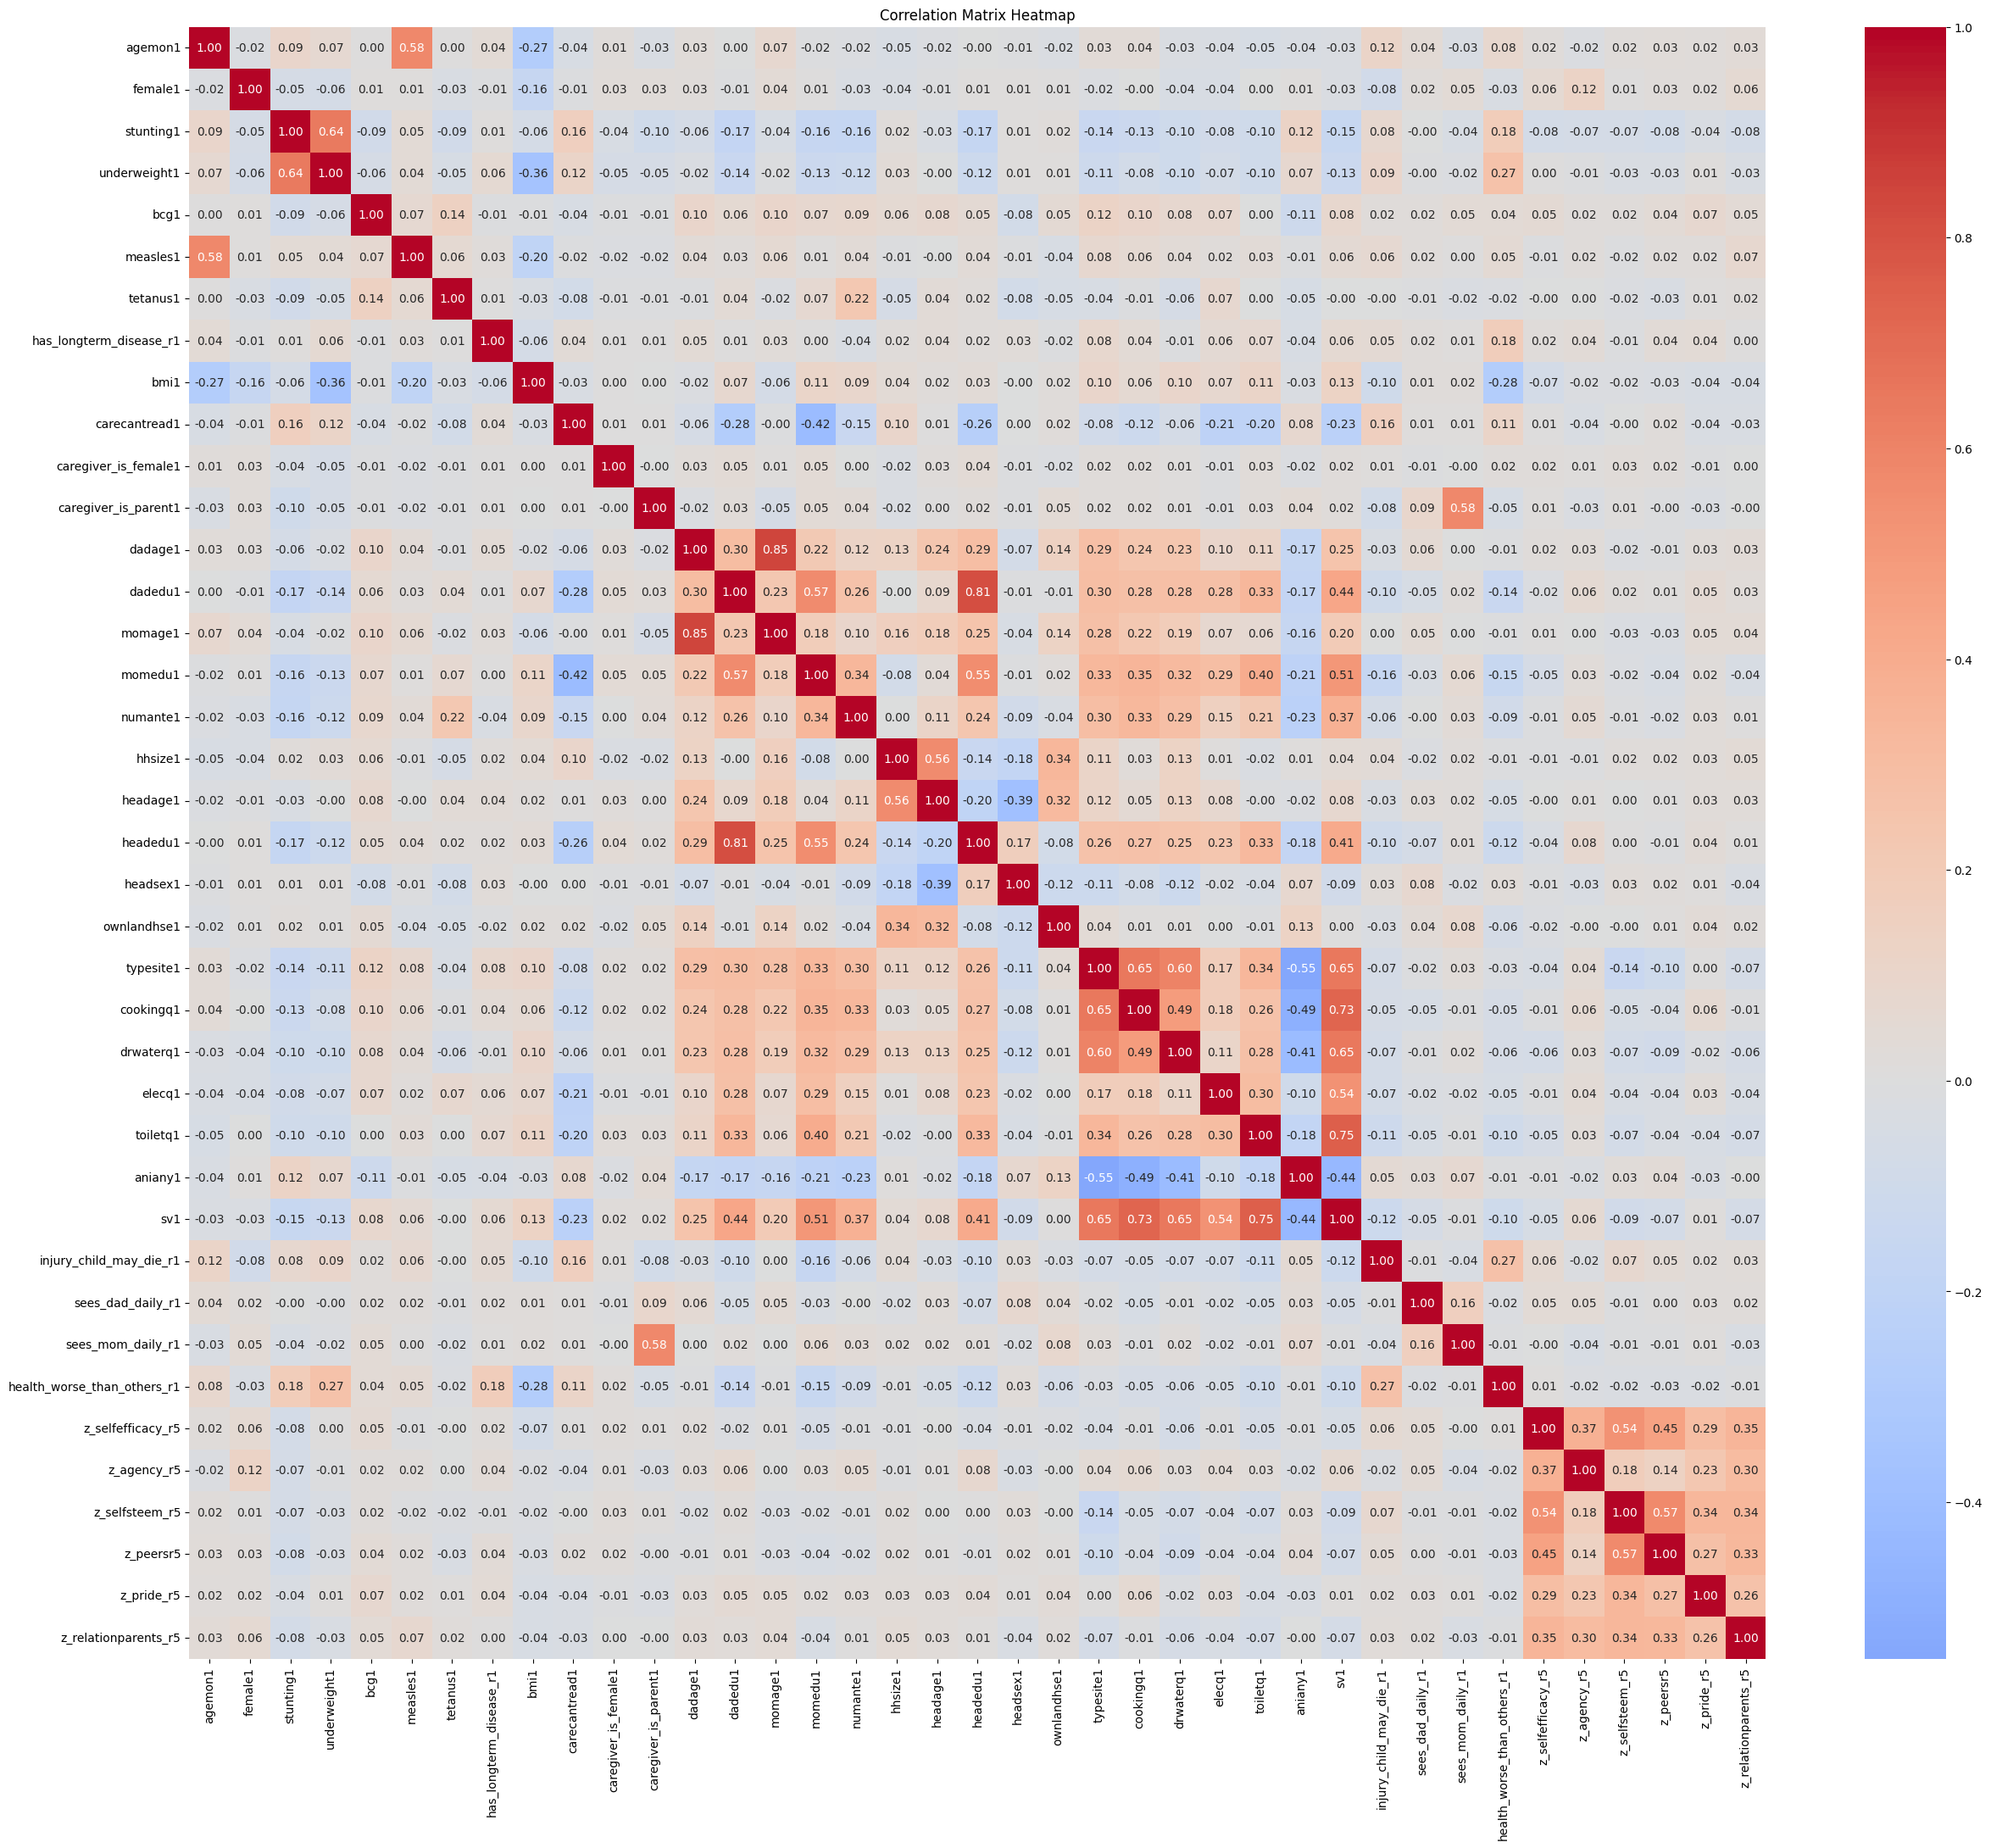

In [271]:
plt.figure(figsize=(30, 25))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [74]:
X.columns

Index(['agemon1', 'female1', 'stunting1', 'underweight1', 'bcg1', 'measles1',
       'tetanus1', 'has_longterm_disease_r1', 'bmi1', 'carecantread1',
       'caregiver_is_female1', 'caregiver_is_parent1', 'dadage1', 'dadedu1',
       'momage1', 'momedu1', 'numante1', 'hhsize1', 'headage1', 'headedu1',
       'headsex1', 'ownlandhse1', 'typesite1', 'cookingq1', 'drwaterq1',
       'elecq1', 'toiletq1', 'aniany1', 'sv1', 'injury_child_may_die_r1',
       'sees_dad_daily_r1', 'sees_mom_daily_r1',
       'health_worse_than_others_r1'],
      dtype='object')

# ANN using pytorch

## Scale

In [155]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [156]:
X_scaled.shape

(1192, 33)

## PCA

In [159]:
pca = PCA(n_components=22)
X_pca = pca.fit_transform(X_scaled)

print("Number of PCA components:", pca.n_components_)
print("Explained variance ratio:", sum(pca.explained_variance_ratio_))
X_pca.shape

Number of PCA components: 22
Explained variance ratio: 0.8972665915672366


(1192, 22)

Text(0, 0.5, 'Cumulative Explained Variance')

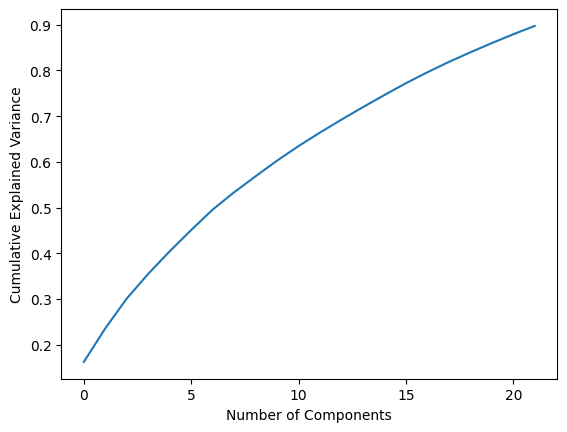

In [160]:
# Plot explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

## Splitting data

In [272]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [273]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [274]:
pca = PCA(n_components=0.95) # Keep components explaining 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [275]:
X_train_pca.shape

(953, 26)

In [117]:
# X_train
# X_test
# y_train
# y_test

## ANN

In [368]:
# class MLP(nn.Module):
#     def __init__(self, input_size, output_size, hidden_size=64):
#         super(MLP, self).__init__()
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.relu1 = nn.ReLU()
#         self.fc2 = nn.Linear(hidden_size, hidden_size)
#         self.relu2 = nn.ReLU()
#         self.fc3 = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         out = self.fc1(x)
#         out = self.relu1(out)
#         out = self.fc2(out)
#         out = self.relu2(out)
#         out = self.fc3(out)
#         return out

class Net(nn.Module):
    def __init__(self, input_size, output_size):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)  # Example: First hidden layer with 64 neurons
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)   # Example: Second hidden layer with 32 neurons
        self.fc3 = nn.Linear(32, output_size) # Output layer with 6 neurons

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [369]:
# Convert NumPy arrays or DataFrame values to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32) # Use .values to convert DataFrame to NumPy array
X_test_tensor = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32) # Use .values to convert DataFrame to NumPy array

# Create TensorDatasets and DataLoaders for efficient batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [370]:
batch_size = 32  # You can adjust this variable
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [377]:
# Initialize the model
input_size = X_train_pca.shape[1]  # 22
output_size = y_train.shape[1] # 6
hidden_size = 128 # You can adjust this variable
model = MLP(input_size, output_size, hidden_size)

In [378]:
# Define loss function and optimizer
learning_rate = 0.000001 # You can adjust this variable
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [383]:
# Training loop
num_epochs = 1000 # You can adjust this variable
train_losses = []
val_losses = []

In [384]:
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for inputs, targets in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * inputs.size(0)
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation loop
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item() * inputs.size(0)
    avg_val_loss = total_val_loss / len(test_loader.dataset)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')


Epoch [10/1000], Train Loss: 1.0011, Val Loss: 0.9380
Epoch [20/1000], Train Loss: 1.0008, Val Loss: 0.9380
Epoch [30/1000], Train Loss: 1.0004, Val Loss: 0.9380
Epoch [40/1000], Train Loss: 1.0000, Val Loss: 0.9379
Epoch [50/1000], Train Loss: 0.9997, Val Loss: 0.9379
Epoch [60/1000], Train Loss: 0.9993, Val Loss: 0.9379
Epoch [70/1000], Train Loss: 0.9989, Val Loss: 0.9379
Epoch [80/1000], Train Loss: 0.9986, Val Loss: 0.9378
Epoch [90/1000], Train Loss: 0.9982, Val Loss: 0.9378
Epoch [100/1000], Train Loss: 0.9978, Val Loss: 0.9378
Epoch [110/1000], Train Loss: 0.9975, Val Loss: 0.9378
Epoch [120/1000], Train Loss: 0.9971, Val Loss: 0.9378
Epoch [130/1000], Train Loss: 0.9968, Val Loss: 0.9377
Epoch [140/1000], Train Loss: 0.9964, Val Loss: 0.9377
Epoch [150/1000], Train Loss: 0.9961, Val Loss: 0.9377
Epoch [160/1000], Train Loss: 0.9957, Val Loss: 0.9377
Epoch [170/1000], Train Loss: 0.9954, Val Loss: 0.9377
Epoch [180/1000], Train Loss: 0.9950, Val Loss: 0.9377
Epoch [190/1000], T

In [385]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    mse = mean_squared_error(y_test.values, test_outputs.numpy()) # Use .values here as well
    r2 = r2_score(y_test.values, test_outputs.numpy()) # Use .values here as well

print(f'\nMean Squared Error on Test Set: {mse:.4f}')

print(f'R-squared on Test Set: {r2:.4f}')


Mean Squared Error on Test Set: 0.9389
R-squared on Test Set: -0.0065


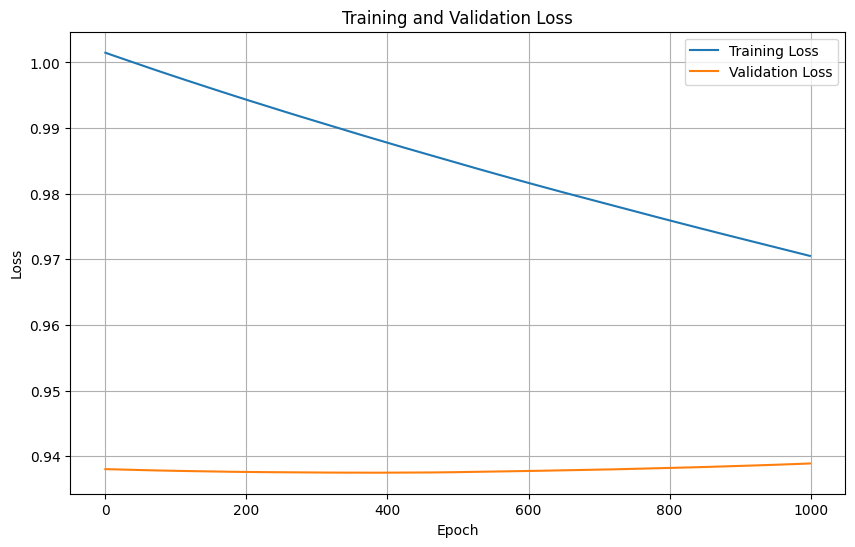

In [386]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()